# Xây dựng cây quyết định ID3

## Khởi tạo dữ liệu

In [2]:
import pandas as pd

# Tạo DataFrame từ dữ liệu trích xuất trong bảng
data = {
    "Day": [f"D{i}" for i in range(1, 15)],
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Rainy", "Sunny", "Overcast", "Overcast", "Rainy"],
    "Temp": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool", "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Windy": ["False", "True", "False", "False", "False", "True", "True", "False", "False", "False", "True", "True", "False", "True"],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data)

# Lưu thành file CSV
csv_path = "weather_data.csv"
df.to_csv(csv_path, index=False)

df

,Day,Outlook,Temp,Humidity,Windy,Play
0,D1,Sunny,Hot,High,False,No
1,D2,Sunny,Hot,High,True,No
2,D3,Overcast,Hot,High,False,Yes
3,D4,Rainy,Mild,High,False,Yes
4,D5,Rainy,Cool,Normal,False,Yes
5,D6,Rainy,Cool,Normal,True,No
6,D7,Overcast,Cool,Normal,True,Yes
7,D8,Sunny,Mild,High,False,No
8,D9,Sunny,Cool,Normal,False,Yes
9,D10,Rainy,Mild,Normal,False,Yes


## Sử dụng hệ số Gain để xây dựng cây quyết định

{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rainy': {'Windy': {'False': 'Yes', 'True': 'No'}}}}


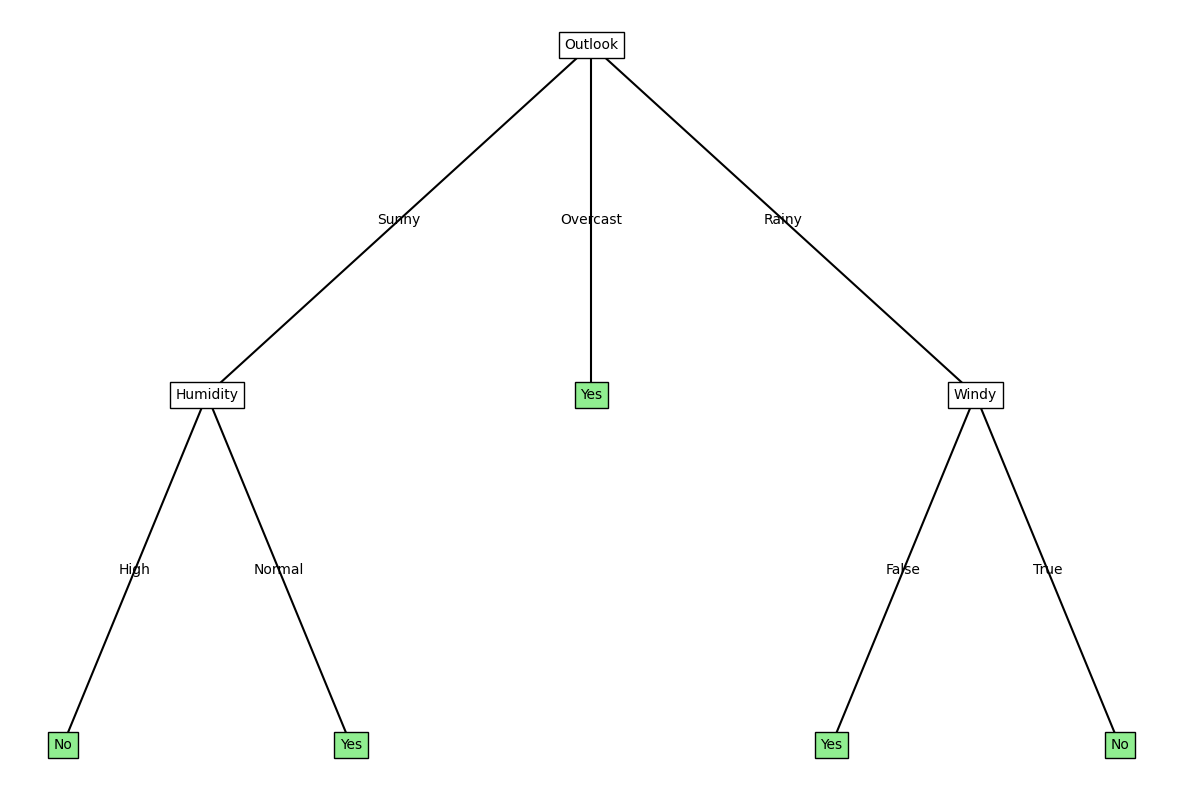

In [7]:
import numpy as np

if 'Day' in df.columns:
    df = df.drop(columns=['Day'])
# Tính entropy của tập dữ liệu
def calculate_entropy(data, target_attribute):
    total_samples = len(data)
    entropy = 0
    for class_value in data[target_attribute].unique():
        p_class = len(data[data[target_attribute] == class_value]) / total_samples
        if p_class > 0:
            entropy -= p_class * np.log2(p_class)
    return entropy

# Tính hệ số Gain cho từng thuộc tính
def calculate_gain(data, attribute, target_attribute):
    total_entropy = calculate_entropy(data, target_attribute)
    attribute_values = data[attribute].unique()
    weighted_entropy = 0
    for value in attribute_values:
        subset = data[data[attribute] == value]
        weighted_entropy += (len(subset) / len(data)) * calculate_entropy(subset, target_attribute)
    return total_entropy - weighted_entropy

# Tạo cây quyết định ID3
def gain_id3_decision_tree(data, target_attribute):
    if len(data[target_attribute].unique()) == 1:
        return data[target_attribute].unique()[0]
    
    if len(data.columns.drop(target_attribute)) == 0:
        return data[target_attribute].mode()[0]
    
    best_attribute = max(
        data.columns.drop(target_attribute),
        key=lambda attr: calculate_gain(data, attr, target_attribute)
    )
    
    tree = {best_attribute: {}}
    for value in data[best_attribute].unique():
        subset = data[data[best_attribute] == value].drop(columns=[best_attribute])
        tree[best_attribute][value] = gain_id3_decision_tree(subset, target_attribute)
    return tree

# Gọi hàm
tree = gain_id3_decision_tree(df, 'Play')
print(tree)

# Vẽ cây quyết định
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
def visualize_tree(tree, parent_name="", level=0):
    plt.figure(figsize=(15, 10))
    
    def plot_node(tree, parent_pos, current_pos, level):
        if isinstance(tree, dict):
            attribute = list(tree.keys())[0]
            plt.plot([parent_pos[0], current_pos[0]], [parent_pos[1], current_pos[1]], 'k-')
            plt.text(current_pos[0], current_pos[1], attribute, 
                    bbox=dict(facecolor='white', edgecolor='black'),
                    ha='center', va='center')
            
            num_children = len(tree[attribute])
            width = 2.0 / (2 ** level)
            
            for i, (value, subtree) in enumerate(tree[attribute].items()):
                child_x = current_pos[0] - width/2 + (i+0.5)*width/num_children
                child_y = current_pos[1] - 1
                child_pos = (child_x, child_y)
                
                # Draw edge label
                mid_x = (current_pos[0] + child_x) / 2
                mid_y = (current_pos[1] + child_y) / 2
                plt.text(mid_x, mid_y, str(value), ha='center', va='center')
                
                plot_node(subtree, current_pos, child_pos, level+1)
        else:
            plt.plot([parent_pos[0], current_pos[0]], [parent_pos[1], current_pos[1]], 'k-')
            plt.text(current_pos[0], current_pos[1], str(tree),
                    bbox=dict(facecolor='lightgreen', edgecolor='black'),
                    ha='center', va='center')

    root_pos = (0, 0)
    plot_node(tree, root_pos, root_pos, 1)
    
    plt.axis('off')
    plt.show()

# Vẽ cây quyết định
visualize_tree(tree)

In [4]:
# Tạo luật từ cây quyết định
def extract_rules(tree, current_rule=None, rules=None):
    if rules is None:
        rules = []
    if current_rule is None:
        current_rule = []

    if not isinstance(tree, dict):
        # Đến lá: thêm luật hoàn chỉnh
        rule = "IF " + " AND ".join(current_rule) + f" THEN Play = {tree}"
        rules.append(rule)
        return rules

    # Duyệt qua các nhánh
    attribute = next(iter(tree))
    for value, subtree in tree[attribute].items():
        condition = f"{attribute} = {value}"
        extract_rules(subtree, current_rule + [condition], rules)

    return rules

# Tạo luật từ cây quyết định
rules = extract_rules(tree)

# In ra các luật
for rule in rules:
    print(rule)

IF Outlook = Sunny AND Humidity = High THEN Play = No
IF Outlook = Sunny AND Humidity = Normal THEN Play = Yes
IF Outlook = Overcast THEN Play = Yes
IF Outlook = Rainy AND Windy = False THEN Play = Yes
IF Outlook = Rainy AND Windy = True THEN Play = No


## Sử dụng hệ số Gini để xây dựng cây quyết định

{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rainy': {'Windy': {'False': 'Yes', 'True': 'No'}}}}


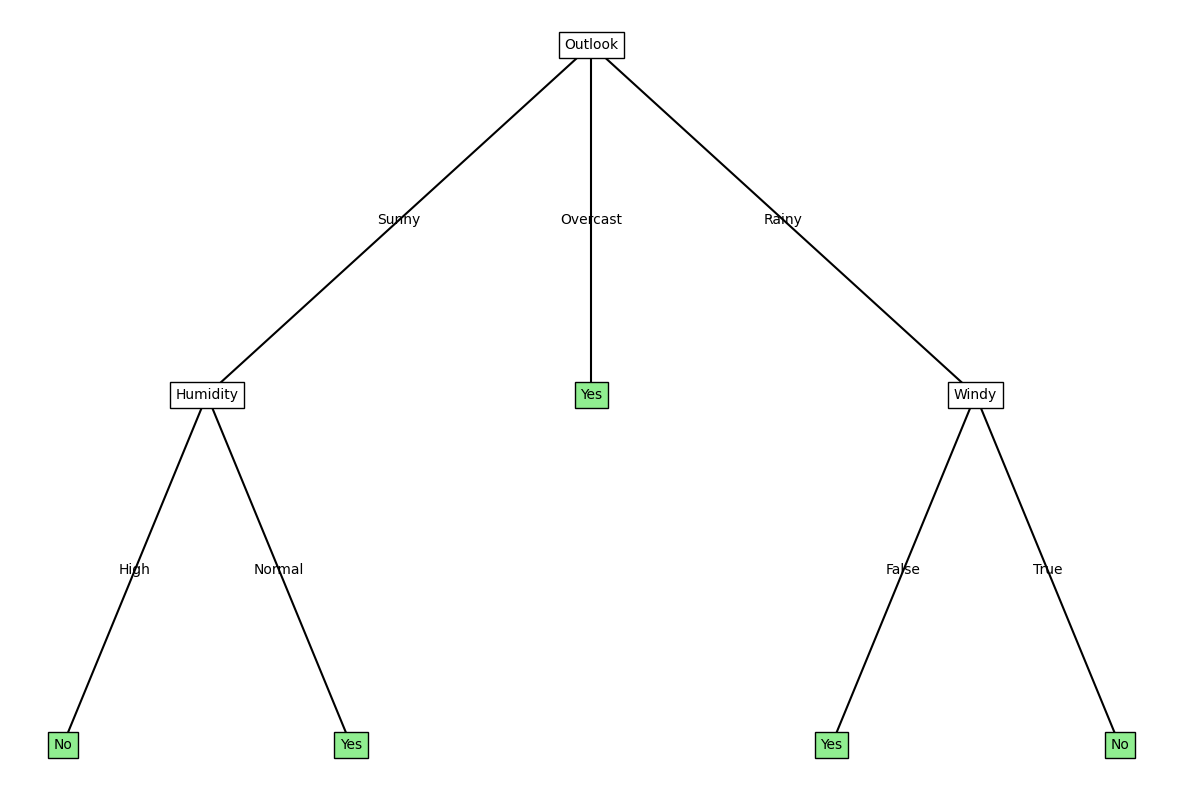

IF Outlook = Sunny AND Humidity = High THEN Play = No
IF Outlook = Sunny AND Humidity = Normal THEN Play = Yes
IF Outlook = Overcast THEN Play = Yes
IF Outlook = Rainy AND Windy = False THEN Play = Yes
IF Outlook = Rainy AND Windy = True THEN Play = No


In [8]:
## Sử dụng hệ số Gini để xây dựng cây quyết định
import numpy as np

# Tính hệ số Gini cho từng thuộc tính
def calculate_gini(data, attribute, target_attribute):
    total_samples = len(data)
    weighted_gini = 0
    
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        subset_size = len(subset)
        
        gini = 1
        for class_value in subset[target_attribute].unique():
            p = len(subset[subset[target_attribute] == class_value]) / subset_size
            gini -= p ** 2
        
        weighted_gini += (subset_size / total_samples) * gini

    return weighted_gini

# Tạo cây quyết định ID3 
def gini_id3_decision_tree(data, target_attribute):
    if len(data[target_attribute].unique()) == 1:
        return data[target_attribute].unique()[0]
    
    if len(data.columns.drop(target_attribute)) == 0:
        return data[target_attribute].mode()[0]
    
    best_attribute = min(
        data.columns.drop(target_attribute),
        key=lambda attr: calculate_gini(data, attr, target_attribute)
    )
    
    tree = {best_attribute: {}}
    for value in data[best_attribute].unique():
        subset = data[data[best_attribute] == value].drop(columns=[best_attribute])
        
        if subset.empty:
            tree[best_attribute][value] = data[target_attribute].mode()[0]
        else:
            tree[best_attribute][value] = gini_id3_decision_tree(subset, target_attribute)
    return tree

# Gọi hàm
tree = gini_id3_decision_tree(df, 'Play')
print(tree)

# Vẽ cây quyết định
visualize_tree(tree)

# Tạo luật từ cây quyết định
rules = extract_rules(tree)

# In ra các luật
for rule in rules:
    print(rule)